# Setup

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Check for CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda:3')  # Use GPU X if available
else:
    device = torch.device('cpu')     # Fallback to CPU if no GPU is available
    
print(device)


cuda:3


# Read data

In [3]:
folder_path = '/raid/sepideh/Project_MCL/1D-AEMpy-UW-metabolism-BM'
file_path = os.path.join(folder_path, "all_data_lake_modeling_process_based.csv")

df = pd.read_csv(file_path)

In [4]:
all_columns= ['depth', 
            'day_of_year_list', 'time_of_day_list', # time features
            'temp_initial00', 'do_ax01', 'docr_initial00', 'docl_initial00', 'pocr_initial00', 'pocl_initial00',
            'area_input', 'volume_input', 'ice_final06',
            'Air_Temperature_celsius', 'Cloud_Cover', 'ea', 'Shortwave_Radiation_Downwelling_wattPerMeterSquared' , 'Longwave_Radiation_Downwelling_wattPerMeterSquared',
            'tp_initial' ,
            'do_bc02', 'docr_bc02', 'docl_bc02', 'pocr_bc02', 'pocl_bc02', 'npp_bc02' # output
                ]
df_m = df[all_columns]
df_m.head()

,depth,day_of_year_list,time_of_day_list,temp_initial00,do_ax01,docr_initial00,docl_initial00,pocr_initial00,pocl_initial00,area_input,...,ea,Shortwave_Radiation_Downwelling_wattPerMeterSquared,Longwave_Radiation_Downwelling_wattPerMeterSquared,tp_initial,do_bc02,docr_bc02,docl_bc02,pocr_bc02,pocl_bc02,npp_bc02
0,0.0,138,18,15.8,2.223120e+08,1.000808e+08,19925000.0,9962500.0,9962500.0,38887500.0,...,10.359133,93.727997,322.450012,37.097143,2.230776e+08,1.000912e+08,1.998307e+07,9.963798e+06,1.019349e+07,79.754379
1,1.0,138,18,15.6,2.199650e+08,9.444510e+07,18962500.0,9481250.0,9481250.0,36962500.0,...,10.359133,93.727997,322.450012,37.097143,2.204061e+08,9.445548e+07,1.899623e+07,9.482548e+06,9.614867e+06,45.944341
2,2.0,138,18,15.4,2.097000e+08,8.889075e+07,18000000.0,9000000.0,9000000.0,35500000.0,...,10.359133,93.727997,322.450012,37.097143,2.099567e+08,8.890113e+07,1.801990e+07,9.001298e+06,9.078311e+06,26.740621
3,3.0,138,18,15.2,2.056250e+08,8.568219e+07,17500000.0,8750000.0,8750000.0,34500000.0,...,10.359133,93.727997,322.450012,37.097143,2.057773e+08,8.569257e+07,1.751207e+07,8.751298e+06,8.796989e+06,15.864943
4,4.0,138,18,14.8,2.014500e+08,8.251588e+07,17000000.0,8500000.0,8500000.0,33525000.0,...,10.359133,93.727997,322.450012,37.097143,2.015404e+08,8.252626e+07,1.700743e+07,8.501298e+06,8.528432e+06,9.421582


# Preprocessing

In [5]:
# Specify input and output columns

input_binary = ['ice_final06'] # remain unchanged

output_columns = ['do_bc02', 'docr_bc02', 'docl_bc02', 'pocr_bc02', 'pocl_bc02', 'npp_bc02']

features_to_normalize = list(set(all_columns) - set(input_binary))
features_to_normalize



['pocl_initial00',
 'docr_initial00',
 'tp_initial',
 'area_input',
 'Cloud_Cover',
 'pocr_initial00',
 'time_of_day_list',
 'pocr_bc02',
 'npp_bc02',
 'Air_Temperature_celsius',
 'ea',
 'Shortwave_Radiation_Downwelling_wattPerMeterSquared',
 'do_ax01',
 'temp_initial00',
 'docr_bc02',
 'docl_initial00',
 'volume_input',
 'pocl_bc02',
 'Longwave_Radiation_Downwelling_wattPerMeterSquared',
 'do_bc02',
 'day_of_year_list',
 'docl_bc02',
 'depth']

### Split data train-val-test

In [6]:

training_frac = 0.60
val_frac = 0.2

depth_steps = 50
number_days = len(df_m)//depth_steps

# Calculate number of observations for each set
n_obs_train = int(number_days * training_frac) * depth_steps
n_obs_val = int(number_days * val_frac) * depth_steps

print(f"Number of days total: {number_days}")


Number of days total: 43800


In [7]:
train_df = df_m.iloc[:n_obs_train]
val_df = df_m.iloc[n_obs_train:n_obs_train + n_obs_val]
test_df = df_m.iloc[n_obs_train + n_obs_val:]

print(f"Number of training points: {train_df.shape}")
print(f"Number of validation points: {val_df.shape}")
print(f"Number of test points: {test_df.shape}")

Number of training points: (1314000, 24)
Number of validation points: (438000, 24)
Number of test points: (438000, 24)


In [8]:
train_df

,depth,day_of_year_list,time_of_day_list,temp_initial00,do_ax01,docr_initial00,docl_initial00,pocr_initial00,pocl_initial00,area_input,...,ea,Shortwave_Radiation_Downwelling_wattPerMeterSquared,Longwave_Radiation_Downwelling_wattPerMeterSquared,tp_initial,do_bc02,docr_bc02,docl_bc02,pocr_bc02,pocl_bc02,npp_bc02
0,0.0,138,18,15.800000,2.223120e+08,1.000808e+08,1.992500e+07,9.962500e+06,9.962500e+06,38887500.0,...,10.359133,93.727997,322.450012,37.097143,2.230776e+08,1.000912e+08,1.998307e+07,9.963798e+06,1.019349e+07,7.975438e+01
1,1.0,138,18,15.600000,2.199650e+08,9.444510e+07,1.896250e+07,9.481250e+06,9.481250e+06,36962500.0,...,10.359133,93.727997,322.450012,37.097143,2.204061e+08,9.445548e+07,1.899623e+07,9.482548e+06,9.614867e+06,4.594434e+01
2,2.0,138,18,15.400000,2.097000e+08,8.889075e+07,1.800000e+07,9.000000e+06,9.000000e+06,35500000.0,...,10.359133,93.727997,322.450012,37.097143,2.099567e+08,8.890113e+07,1.801990e+07,9.001298e+06,9.078311e+06,2.674062e+01
3,3.0,138,18,15.200000,2.056250e+08,8.568219e+07,1.750000e+07,8.750000e+06,8.750000e+06,34500000.0,...,10.359133,93.727997,322.450012,37.097143,2.057773e+08,8.569257e+07,1.751207e+07,8.751298e+06,8.796989e+06,1.586494e+01
4,4.0,138,18,14.800000,2.014500e+08,8.251588e+07,1.700000e+07,8.500000e+06,8.500000e+06,33525000.0,...,10.359133,93.727997,322.450012,37.097143,2.015404e+08,8.252626e+07,1.700743e+07,8.501298e+06,8.528432e+06,9.421582e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,45.0,137,17,7.341026,1.278520e+07,5.891944e+06,6.306292e+05,5.634754e+04,2.096470e+06,2075000.0,...,15.623983,284.911011,343.950012,98.532246,1.278520e+07,5.891944e+06,6.306292e+05,5.634754e+04,2.096470e+06,1.587121e-06
1313996,46.0,137,17,7.241680,7.404354e+06,3.699436e+06,3.989957e+05,4.926397e+04,1.832914e+06,1225000.0,...,15.623983,284.911011,343.950012,98.532246,7.404354e+06,3.699436e+06,3.989957e+05,4.926397e+04,1.832914e+06,7.049257e-07
1313997,47.0,137,17,6.963334,3.178492e+06,1.969131e+06,2.169789e+05,4.216239e+04,1.568691e+06,475000.0,...,15.623983,284.911011,343.950012,98.532246,3.178492e+06,1.969131e+06,2.169789e+05,4.216239e+04,1.568691e+06,2.614312e-07
1313998,48.0,137,17,6.032399,1.172362e+05,2.331755e+05,2.755004e+04,3.531220e+04,1.313822e+06,75000.0,...,15.623983,284.911011,343.950012,98.532246,1.172362e+05,2.331755e+05,2.755004e+04,3.531220e+04,1.313822e+06,2.041775e-08


### Normalize other features

In [9]:
features_to_normalize

['pocl_initial00',
 'docr_initial00',
 'tp_initial',
 'area_input',
 'Cloud_Cover',
 'pocr_initial00',
 'time_of_day_list',
 'pocr_bc02',
 'npp_bc02',
 'Air_Temperature_celsius',
 'ea',
 'Shortwave_Radiation_Downwelling_wattPerMeterSquared',
 'do_ax01',
 'temp_initial00',
 'docr_bc02',
 'docl_initial00',
 'volume_input',
 'pocl_bc02',
 'Longwave_Radiation_Downwelling_wattPerMeterSquared',
 'do_bc02',
 'day_of_year_list',
 'docl_bc02',
 'depth']

In [10]:
train_features_to_normalize = train_df[features_to_normalize].values
val_data_features_to_normalize = val_df[features_to_normalize].values
test_features_to_normalize = test_df[features_to_normalize].values

In [11]:
# Initialize StandardScaler and fit on training features
scaler = StandardScaler()
scaler.fit(train_features_to_normalize)

# Transform training, test, and validation features using the fitted scaler
train_df[features_to_normalize] = scaler.transform(train_features_to_normalize)
val_df[features_to_normalize] = scaler.transform(val_data_features_to_normalize)
test_df[features_to_normalize] = scaler.transform(test_features_to_normalize)

In [12]:
train_df

,depth,day_of_year_list,time_of_day_list,temp_initial00,do_ax01,docr_initial00,docl_initial00,pocr_initial00,pocl_initial00,area_input,...,ea,Shortwave_Radiation_Downwelling_wattPerMeterSquared,Longwave_Radiation_Downwelling_wattPerMeterSquared,tp_initial,do_bc02,docr_bc02,docl_bc02,pocr_bc02,pocl_bc02,npp_bc02
0,-1.697749,-0.428508,0.939010,1.392066,1.834876,2.424161,4.387237,20.603536,0.892500,1.819655,...,-0.090262,-0.332610,0.333878,-1.171899,1.843013,2.424160,4.389883,20.604998,0.923367,1.640966
1,-1.628453,-0.428508,0.939010,1.359058,1.801767,2.182692,4.103527,19.589826,0.807058,1.639226,...,-0.090262,-0.332610,0.333878,-1.171899,1.805363,2.182724,4.099866,19.591316,0.821412,0.888910
2,-1.559158,-0.428508,0.939010,1.326050,1.656958,1.944708,3.819816,18.576116,0.721616,1.502148,...,-0.090262,-0.332610,0.333878,-1.171899,1.658102,1.944772,3.812939,18.577634,0.726870,0.461751
3,-1.489862,-0.428508,0.939010,1.293042,1.599472,1.807232,3.672434,18.049514,0.677230,1.408419,...,-0.090262,-0.332610,0.333878,-1.171899,1.599202,1.807315,3.663696,18.051046,0.677301,0.219837
4,-1.420566,-0.428508,0.939010,1.227026,1.540575,1.671567,3.525052,17.522911,0.632845,1.317033,...,-0.090262,-0.332610,0.333878,-1.171899,1.539492,1.671668,3.515390,17.524458,0.629981,0.076514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,1.420566,-0.437986,0.794547,-0.004001,-1.120931,-1.611498,-1.300055,-0.262880,-0.504053,-1.630744,...,0.593412,0.463549,0.655860,0.204843,-1.120614,-1.611394,-1.297487,-0.263583,-0.503341,-0.133055
1313996,1.489862,-0.437986,0.794547,-0.020397,-1.196839,-1.705439,-1.368332,-0.277800,-0.550845,-1.710414,...,0.593412,0.463549,0.655860,0.204843,-1.196445,-1.705322,-1.365560,-0.278504,-0.549780,-0.133055
1313997,1.559158,-0.437986,0.794547,-0.066335,-1.256453,-1.779577,-1.421984,-0.292759,-0.597756,-1.780710,...,0.593412,0.463549,0.655860,0.204843,-1.256000,-1.779450,-1.419052,-0.293462,-0.596337,-0.133055
1313998,1.628453,-0.437986,0.794547,-0.219977,-1.299639,-1.853956,-1.477821,-0.307189,-0.643006,-1.818202,...,0.593412,0.463549,0.655860,0.204843,-1.299142,-1.853819,-1.474722,-0.307891,-0.641245,-0.133055


# Training 

In [13]:
# the deep neural network
class MLP(torch.nn.Module):
    def __init__(self, layers, activation="relu", init="xavier", dropout_rate=0.2):
        super(MLP, self).__init__()
        
        # parameters
        self.depth = len(layers) - 1
        self.dropout_rate = dropout_rate
        if activation == "relu":
            self.activation = torch.nn.ReLU()
        elif activation == "tanh":
            self.activation = torch.nn.Tanh()
        elif activation == "gelu":
            self.activation = torch.nn.GELU()
        else:
            raise ValueError("Unspecified activation type")
        
        
        layer_list = list()
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation))
            layer_list.append(('dropout_%d' % i, torch.nn.Dropout(p=self.dropout_rate)))
            
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        
        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

        if init=="xavier":
            self.xavier_init_weights()
        elif init=="kaiming":
            self.kaiming_init_weights()
    
    def xavier_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Xavier Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.xavier_uniform_(m.weight)
                    m.bias.data.fill_(0.0)

    def kaiming_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Kaiming Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.kaiming_uniform_(m.weight)
                    m.bias.data.fill_(0.0)
                        
    def forward(self, x):
        out = self.layers(x)
        return out
    
class DataGenerator(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
    def __len__(self):
        return len(self.X)

In [14]:
input_columns = [column for column in train_df.columns if column not in output_columns]

input_column_ix = [train_df.columns.get_loc(column) for column in input_columns]
output_column_ix = [train_df.columns.get_loc(column) for column in output_columns]

train_array = train_df.values
test_array = test_df.values
val_array = val_df.values

# Use the column indices to select the input and output data
X_train, X_test, X_val = train_array[:,input_column_ix], test_array[:,input_column_ix], val_array[:, input_column_ix]
y_train, y_test, y_val = train_array[:,output_column_ix], test_array[:,output_column_ix], val_array[:, output_column_ix]


In [15]:
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")


X_train: (1314000, 18), X_val: (438000, 18), X_test: (438000, 18)
y_train: (1314000, 6), y_val: (438000, 6), y_test: (438000, 6)


In [16]:
# Create data set
batch_size = 1024
train_dataset = DataGenerator(X_train, y_train)
val_dataset = DataGenerator(X_val, y_val)
test_dataset = DataGenerator(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)

In [17]:
layers = [X_train.shape[-1], 32, 32, y_train.shape[-1]]

dropout_rate = 0.00001
model = MLP(layers, activation="gelu", dropout_rate=dropout_rate).to(device)

Initializing Network with Xavier Initialization..


In [18]:
lr = 1e-4
decay_rate = 0.5
decay_steps = 500
    
optimizer = torch.optim.Adam(model.parameters(), lr=lr, 
                         betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-4, amsgrad=False)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_steps, gamma=decay_rate)

criterion = torch.nn.MSELoss()

In [19]:
print(model)


MLP(
  (activation): GELU(approximate='none')
  (layers): Sequential(
    (layer_0): Linear(in_features=18, out_features=32, bias=True)
    (activation_0): GELU(approximate='none')
    (dropout_0): Dropout(p=1e-05, inplace=False)
    (layer_1): Linear(in_features=32, out_features=32, bias=True)
    (activation_1): GELU(approximate='none')
    (dropout_1): Dropout(p=1e-05, inplace=False)
    (layer_2): Linear(in_features=32, out_features=6, bias=True)
  )
)


In [20]:
n_epochs = 100

train_loss = []
val_loss = []
for it in tqdm(range(n_epochs)):
    loss_epoch = 0
    model.train()
    for x, y in iter(train_loader):
        x, y = x.to(device).float(), y.to(device).float()
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach().item()
    lr_scheduler.step()
    
    if it % 1 == 0:
        train_loss.append(loss_epoch/len(train_loader))
        model.eval()
        val_loss_epoch = 0
        for x, y in iter(val_loader):
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            loss = criterion(pred, y)
            val_loss_epoch += loss.detach().item()
        val_loss.append(val_loss_epoch/len(val_loader))
        print(f"Epoch : {it}, Train_loss: {train_loss[-1]}, Val_loss: {val_loss[-1]}")
    

  1%|          | 1/100 [00:16<26:30, 16.07s/it]

Epoch : 0, Train_loss: 0.3910251948402214, Val_loss: 0.1011705071269317


  2%|▏         | 2/100 [00:31<25:47, 15.79s/it]

Epoch : 1, Train_loss: 0.1269889483431418, Val_loss: 0.06458449588923185


  3%|▎         | 3/100 [00:47<25:41, 15.89s/it]

...

Epoch : 97, Train_loss: 0.002169713713961285, Val_loss: 0.002307038359997074


 99%|█████████▉| 99/100 [26:06<00:15, 15.62s/it]

Epoch : 98, Train_loss: 0.002167647838803963, Val_loss: 0.0022082190723871054


100%|██████████| 100/100 [26:22<00:00, 15.82s/it]

Epoch : 99, Train_loss: 0.0021887742220663476, Val_loss: 0.0027456077452336666


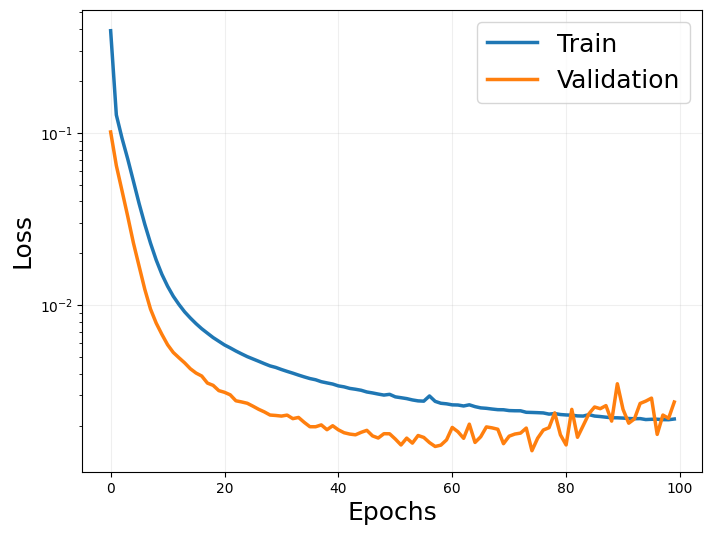

In [21]:
plt.figure(figsize=(8,6))
plt.plot(train_loss, label="Train", linewidth=2.5)
plt.plot(val_loss, label="Validation", linewidth=2.5)
plt.grid("on", alpha=0.2)
plt.legend(fontsize=18)
plt.yscale("log")
plt.xlabel("Epochs", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.show()

# Evaluating results

In [22]:
def rmse(true, pred):
    return (((true - pred) ** 2).mean() ** 0.5).detach().cpu().numpy()

def l2_error(true, pred):
    return np.linalg.norm(pred.detach().cpu().numpy() - true.detach().cpu().numpy()) / np.linalg.norm(true.detach().cpu().numpy())

def compute_metrics(model, loader, output_columns):
    model.eval()
    preds = []
    ys = []
    for x, y in iter(loader):
        x, y = x.to(device).float(), y.to(device).float()
        pred = model(x)
        
        preds.append(pred)
        ys.append(y)

    ys = torch.cat(ys, dim=0) 
    preds = torch.cat(preds, dim=0)
    
    # Compute RMSE and L2 error for each feature
    rmse_values = []
    l2_error_values = []
    
    for i in range(ys.shape[1]):  # Iterate over each feature
        rmse_temp = rmse(ys[:, i], preds[:, i])
        l2_error_temp = l2_error(ys[:, i], preds[:, i])
        rmse_values.append(rmse_temp)
        l2_error_values.append(l2_error_temp)
        
        print(f"- Feature {output_columns[i]}:  RMSE: {rmse_temp:.5f}, L2 Error: {l2_error_temp:.5f}")
    
    # Compute overall RMSE across all features and samples
    overall_rmse = rmse(ys.flatten(), preds.flatten())
    print(f"Overall RMSE: {overall_rmse:.5f}")
    
    return rmse_values, l2_error_values, overall_rmse, ys, preds


In [23]:
print("Validation Errors: ")
rmse_val, l2_error_val, overall_rmse_val, val_gt, val_pred = compute_metrics(model, val_loader, output_columns)

Validation Errors: 
- Feature do_bc02:  RMSE: 0.01100, L2 Error: 0.01090
- Feature docr_bc02:  RMSE: 0.02340, L2 Error: 0.02393
- Feature docl_bc02:  RMSE: 0.01087, L2 Error: 0.01302
- Feature pocr_bc02:  RMSE: 0.01282, L2 Error: 0.05972
- Feature pocl_bc02:  RMSE: 0.01233, L2 Error: 0.01507
- Feature npp_bc02:  RMSE: 0.12380, L2 Error: 0.15718
Overall RMSE: 0.05233


In [24]:
print("Train Errors: ")
rmse_train, l2_error_train, overall_rmse_val, train_gt, train_pred = compute_metrics(model, train_loader, output_columns)

Train Errors: 
- Feature do_bc02:  RMSE: 0.01133, L2 Error: 0.01133
- Feature docr_bc02:  RMSE: 0.01667, L2 Error: 0.01667
- Feature docl_bc02:  RMSE: 0.01219, L2 Error: 0.01219
- Feature pocr_bc02:  RMSE: 0.01351, L2 Error: 0.01351
- Feature pocl_bc02:  RMSE: 0.01260, L2 Error: 0.01260
- Feature npp_bc02:  RMSE: 0.10795, L2 Error: 0.10795
Overall RMSE: 0.04573


In [25]:
print("Test Errors: ")
rmse_test, l2_error_test, overall_rmse_val, test_gt, test_pred = compute_metrics(model, test_loader, output_columns)

Test Errors: 


- Feature do_bc02:  RMSE: 0.01005, L2 Error: 0.01004
- Feature docr_bc02:  RMSE: 0.02540, L2 Error: 0.02603
- Feature docl_bc02:  RMSE: 0.01061, L2 Error: 0.01260
- Feature pocr_bc02:  RMSE: 0.01266, L2 Error: 0.06029
- Feature pocl_bc02:  RMSE: 0.01279, L2 Error: 0.01540
- Feature npp_bc02:  RMSE: 0.09754, L2 Error: 0.12311
Overall RMSE: 0.04222


# Visualizing result

In [26]:
def prepare_heatmap_data(data, df_main):
    # Create a DataFrame for visualization with depth and time as multi-index
    df = pd.DataFrame(data, columns=['predicted_value'])
    df['depth'] = df_main.reset_index(drop=True)['depth']
    df['datetime'] = df_main.reset_index(drop=True)['datetime'] 
    # Pivot to create a depth vs. time structure suitable for heatmap
    heatmap_data = df.pivot_table(index='depth', columns='datetime', values='predicted_value', aggfunc='mean')
    return heatmap_data

In [27]:
for i in range(test_gt.shape[1]):
    # Prepare the data to plot heatmaps
    test_real_data = prepare_heatmap_data(test_gt.detach().cpu().numpy()[:,i], test_df_unnormalized)
    test_pred_data = prepare_heatmap_data(test_pred.detach().cpu().numpy()[:,i], test_df_unnormalized)
    difference_data = test_real_data - test_pred_data

    # Data for plotting
    heatmap_data = [
        (test_real_data, f'Test Real Values of {output_columns[i]}', 'seismic', 'Test Real Values'),
        (test_pred_data, f'Test Predicted Values of {output_columns[i]}', 'seismic', 'Test Predicted Values'),
        (difference_data, f'Difference Between Real and Predicted {output_columns[i]}', 'seismic', 'Difference (Real - Predicted)')
    ]

    # Plot heatmaps
    fig, axs = plt.subplots(len(heatmap_data), 1, figsize=(15, 15))

    for ax, (data, title, cmap, cbar_label) in zip(axs, heatmap_data):
        sns.heatmap(data, cmap=cmap, ax=ax, cbar_kws={'label': cbar_label}, center=0)
        ax.set_title(title)
        ax.set_xlabel('Time')
        ax.set_ylabel('Depth')

    plt.tight_layout()
    plt.show()
    

NameError: name 'test_df_unnormalized' is not defined

# Saving Model

In [29]:
PATH = f"../saved_models/pretrain/m2.pth"
torch.save(model.state_dict(), PATH)